# Simulation Month — Week 4, Notebook 3
## 40 Disasters, Five Unit Counts, Head-to-Head

This notebook runs 40 independently-seeded disasters through both dispatch strategies, across a range of unit counts, to see whether Notebook 2's crossover is a robust pattern — and closes out Simulation Month by tying the whole arc together.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import os

EMPTY, TREE, BURNING = 0, 1, 2
FIRE_PALETTE = ListedColormap(["#D4A574", "#3D5A45", "#E8871E"])  # sand, forest, ember
UNIT_COLOR = "#2E5C8A"   # steel blue — response units, distinct from the fire palette

NATURAL_PALETTE = {
    "unaware": "#8B5E3C", "engaged": "#6B8E4E", "disengaged": "#3D5A45",
    "accent": "#D4A574", "highlight": "#4A6741",
}

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#3D5A45"
plt.rcParams["font.size"] = 11

FIG_DIR = "/mnt/user-data/outputs/figures"
VIDEO_DIR = "/mnt/user-data/outputs/videos"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

In [2]:
def burning_neighbor_mask(grid):
    burning = (grid == BURNING)
    mask = np.zeros_like(burning)
    mask[1:, :]  |= burning[:-1, :]
    mask[:-1, :] |= burning[1:, :]
    mask[:, 1:]  |= burning[:, :-1]
    mask[:, :-1] |= burning[:, 1:]
    return mask

def step(grid, p, f, rng):
    new_grid = grid.copy()
    burning = grid == BURNING
    tree = grid == TREE
    empty = grid == EMPTY
    neighbor_burning = burning_neighbor_mask(grid)
    new_grid[burning] = EMPTY
    ignite_spread = tree & neighbor_burning
    new_grid[ignite_spread] = BURNING
    remaining_trees = tree & ~neighbor_burning
    lightning_strikes = remaining_trees & (rng.random(grid.shape) < f)
    new_grid[lightning_strikes] = BURNING
    grow = empty & (rng.random(grid.shape) < p)
    new_grid[grow] = TREE
    n_new = int(ignite_spread.sum() + lightning_strikes.sum())
    return new_grid, n_new, lightning_strikes

def seed_forest(size, density, rng):
    grid = np.zeros((size, size), dtype=int)
    grid[rng.random((size, size)) < density] = TREE
    return grid

def nearest_tree_to_center(grid):
    ys, xs = np.where(grid == TREE)
    c = grid.shape[0] // 2
    dists = (ys - c) ** 2 + (xs - c) ** 2
    i = np.argmin(dists)
    return int(ys[i]), int(xs[i])

In [3]:
from scipy.optimize import linear_sum_assignment

def cheby(a, b):
    return max(abs(a[0] - b[0]), abs(a[1] - b[1]))

def get_stations(n_units, size):
    """Place fire stations in a ring around the forest, surrounding it evenly —
    the same station layout is used for both strategies so any outcome
    difference is attributable to dispatch logic, not starting position."""
    center = size / 2
    radius = size * 0.45
    angles = np.linspace(0, 2 * np.pi, n_units, endpoint=False)
    stations = []
    for a in angles:
        y = int(np.clip(center + radius * np.sin(a), 0, size - 1))
        x = int(np.clip(center + radius * np.cos(a), 0, size - 1))
        stations.append((y, x))
    return stations

def assign_centralized(unit_positions, burning_cells, max_candidates=60):
    """A single commander with full visibility assigns units to minimize total
    travel distance, using the Hungarian algorithm for a genuinely optimal
    (not just deduplicated) match. Candidates are capped near the unit
    centroid for speed when the fire front is large."""
    if len(burning_cells) > max_candidates:
        centroid = np.mean(unit_positions, axis=0)
        d = [cheby(centroid, c) for c in burning_cells]
        idx = np.argsort(d)[:max_candidates]
        candidates = [burning_cells[i] for i in idx]
    else:
        candidates = burning_cells

    cost = np.array([[cheby(u, c) for c in candidates] for u in unit_positions])
    row_ind, col_ind = linear_sum_assignment(cost)
    assignments = [None] * len(unit_positions)
    for r, c in zip(row_ind, col_ind):
        assignments[r] = candidates[c]
    return assignments

def assign_decentralized(unit_positions, burning_cells):
    """Each unit independently heads for its own nearest burning cell — no
    coordinator, no visibility into what other units are doing."""
    assignments = []
    for pos in unit_positions:
        if not burning_cells:
            assignments.append(None)
            continue
        best = min(burning_cells, key=lambda c: cheby(pos, c))
        assignments.append(best)
    return assignments

def move_towards(pos, target):
    y, x = pos
    ty, tx = target
    dy = int(np.sign(ty - y))
    dx = int(np.sign(tx - x))
    return (y + dy, x + dx)

def run_response_sim(grid, stations, strategy, rng, max_steps=150, record_frames=False):
    """Each step: units retarget and move one cell toward their target, any unit
    now standing on a burning cell suppresses it, then the fire spreads
    naturally (no growth/lightning — this is a single-disaster response
    scenario, not the ongoing regrowth process from Week 3)."""
    grid = grid.copy()
    units = list(stations)
    suppressed_count = 0
    steps_taken = 0
    frames = [(grid.copy(), list(units))] if record_frames else None

    for t in range(max_steps):
        burning_cells = [tuple(c) for c in np.argwhere(grid == BURNING)]
        if not burning_cells:
            break

        targets = ([] if not units else
                   (assign_centralized(units, burning_cells) if strategy == "centralized"
                    else assign_decentralized(units, burning_cells)))
        units = [pos if target is None else move_towards(pos, target)
                 for pos, target in zip(units, targets)]

        for pos in units:
            if grid[pos[0], pos[1]] == BURNING:
                grid[pos[0], pos[1]] = EMPTY
                suppressed_count += 1

        grid, _, _ = step(grid, p=0.0, f=0.0, rng=rng)
        steps_taken = t + 1
        if record_frames:
            frames.append((grid.copy(), list(units)))
        if not (grid == BURNING).any():
            break

    result = {"final_grid": grid, "suppressed": suppressed_count, "steps": steps_taken}
    if record_frames:
        result["frames"] = frames
    return result

In [4]:
from scipy import stats
import pandas as pd

## Running the full sweep

40 disaster seeds × 5 unit counts × 2 strategies = 400 simulation runs. Each run resolves in well under 150 steps on a 60×60 grid, so the whole sweep finishes quickly.

In [5]:
SIZE = 60
DENSITY = 0.65
N_SEEDS = 40
UNIT_COUNTS = [1, 2, 3, 5, 8]

records = []
for seed in range(N_SEEDS):
    rng = np.random.default_rng(seed)
    base_grid = seed_forest(SIZE, DENSITY, rng)
    iy, ix = nearest_tree_to_center(base_grid)
    base_grid[iy, ix] = BURNING
    initial_trees = int((base_grid == TREE).sum()) + 1

    for n_units in UNIT_COUNTS:
        stations = get_stations(n_units, SIZE)
        for strategy in ["centralized", "decentralized"]:
            r = run_response_sim(base_grid.copy(), stations, strategy, np.random.default_rng(1))
            burned = initial_trees - int((r["final_grid"] == TREE).sum())
            records.append({
                "seed": seed, "n_units": n_units, "strategy": strategy,
                "burned": burned, "burned_frac": burned / initial_trees,
                "steps": r["steps"],
            })

df = pd.DataFrame(records)
print(f"Completed {len(df)} total simulation runs")
df.groupby(["n_units", "strategy"])["burned_frac"].mean().unstack()

Completed 400 total simulation runs


strategy,centralized,decentralized
n_units,,
1,0.769759,0.769653
2,0.628842,0.638319
3,0.426762,0.457758
5,0.267086,0.227376
8,0.160044,0.129460


## The crossover, with real statistical grounding

Mean burned fraction per unit count, with the spread across all 40 seeds — this is the chart that either confirms or debunks Notebook 2's single-run impression.

saved /mnt/user-data/outputs/figures/week4_crossover_chart.png


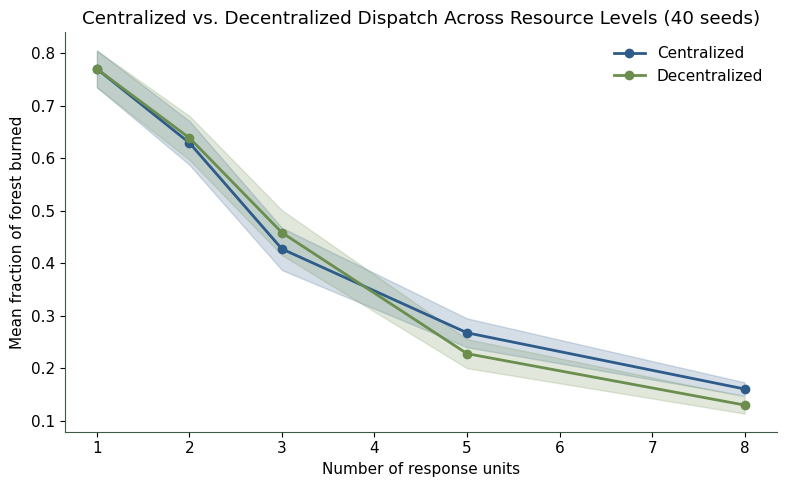

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for strategy, color in [("centralized", "#2E5C8A"), ("decentralized", NATURAL_PALETTE["engaged"])]:
    sub = df[df["strategy"] == strategy].groupby("n_units")["burned_frac"]
    means = sub.mean()
    sems = sub.sem()
    ax.plot(means.index, means.values, "o-", color=color, label=strategy.capitalize(), linewidth=2)
    ax.fill_between(means.index, means.values - sems.values, means.values + sems.values,
                     color=color, alpha=0.2)

ax.set_xlabel("Number of response units")
ax.set_ylabel("Mean fraction of forest burned")
ax.set_title("Centralized vs. Decentralized Dispatch Across Resource Levels (40 seeds)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
savefig(fig, "week4_crossover_chart")
plt.show()

## A paired statistical test at a representative unit count

Since every seed is run through *both* strategies, we can test the difference as a paired comparison rather than treating the two groups as independent samples — a more sensitive test given how much variance comes from the disaster draw itself.

In [7]:
test_units = 8
paired_c = df[(df["n_units"] == test_units) & (df["strategy"] == "centralized")].sort_values("seed")["burned_frac"].values
paired_d = df[(df["n_units"] == test_units) & (df["strategy"] == "decentralized")].sort_values("seed")["burned_frac"].values

stat, p_value = stats.wilcoxon(paired_c, paired_d)
print(f"At {test_units} units: centralized mean burned = {paired_c.mean()*100:.1f}%, "
      f"decentralized mean burned = {paired_d.mean()*100:.1f}%")
print(f"Wilcoxon signed-rank test: statistic={stat:.1f}, p={p_value:.4f}")
print("(a small p-value here means the gap is unlikely to be seed noise)")

At 8 units: centralized mean burned = 16.0%, decentralized mean burned = 12.9%
Wilcoxon signed-rank test: statistic=188.0, p=0.0048
(a small p-value here means the gap is unlikely to be seed noise)


## Interactive explorer: pick a strategy and a resource level

In [8]:
from ipywidgets import interact, IntSlider, Dropdown

def explore(strategy="decentralized", n_units=5, seed=1):
    rng_local = np.random.default_rng(seed)
    base_grid = seed_forest(SIZE, DENSITY, rng_local)
    iy, ix = nearest_tree_to_center(base_grid)
    base_grid[iy, ix] = BURNING
    initial_trees = int((base_grid == TREE).sum()) + 1
    stations = get_stations(n_units, SIZE)

    r = run_response_sim(base_grid.copy(), stations, strategy, np.random.default_rng(1))
    burned = initial_trees - int((r["final_grid"] == TREE).sum())

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(r["final_grid"], cmap=FIRE_PALETTE, vmin=0, vmax=2)
    sy = [s[0] for s in stations]
    sx = [s[1] for s in stations]
    ax.scatter(sx, sy, c=UNIT_COLOR, s=40, marker="^", alpha=0.3, label="Station start")
    ax.set_title(f"{strategy.capitalize()}, {n_units} units: {burned}/{initial_trees} burned "
                 f"({burned/initial_trees*100:.1f}%), {r['steps']} steps")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

interact(explore,
         strategy=Dropdown(options=["centralized", "decentralized"], value="decentralized"),
         n_units=IntSlider(min=1, max=12, step=1, value=5),
         seed=IntSlider(min=1, max=50, step=1, value=1));

interactive(children=(Dropdown(description='strategy', index=1, options=('centralized', 'decentralized'), valu…

## Closing out Simulation Month

Four weeks, four simulations, one throughline: **outcomes are driven by structure and connectivity at least as much as by the size or severity of whatever's spreading.**

- **Week 1** showed a wellness program's adoption curve is shaped by network structure and individual susceptibility, not just word-of-mouth strength
- **Week 2** showed an organization's fragility depends on its team structure — and that "chronically overloaded" and "genuinely critical" are different failure modes, not the same one at different volumes
- **Week 3** showed a wildfire's severity is dominated by forest connectivity relative to a sharp percolation threshold, more than by anything local to the spark
- **Week 4** showed even disaster *response* isn't simply "more coordination is better" — a mathematically optimal centralized coordinator can lose to simple local heuristics once a dynamic environment makes global optimization inconsistent over time

None of these numbers describe any real organization, forest, or emergency response — they're toy models built to make a mechanism visible. But the mechanisms themselves — network effects, self-organized criticality, percolation thresholds, and coordination thrashing — are genuine, well-studied phenomena that show up far beyond these toy examples. That's the trade this whole month made: give up realism to make the *shape* of the argument impossible to miss.